# KNN Applied to Cybersecurity Incidents

This notebook applies the K-Nearest Neighbours algorithm to a real-world cybersecurity dataset. The data comes from three CSV files that we join by incident_id: incidents_master (general incident metadata), financial_impact (economic losses per incident) and market_impact (stock market reaction after disclosure).

We explore two main uses of KNN in this context. First, classification: given the features of a new incident, we want to predict which category it belongs to, such as the type of attack or whether it will cause high or low financial damage. Second, regression: given a company profile, we want to estimate a numeric value like total economic loss, by averaging the values of the most similar past incidents.

The core idea behind KNN is simple: nearby points in feature space tend to belong to the same class. When a new incident arrives, the algorithm finds the K most similar past incidents and lets them vote.

## Imports

We load all the libraries needed throughout the notebook. The most relevant ones for KNN are KNeighborsClassifier, which implements the algorithm, StandardScaler, which is mandatory before any distance-based model, and the evaluation utilities from sklearn.metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import neighbors, datasets
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score


## What we use KNN for

We use KNN in order to achieve two main objectives:
- Classificate, which means we have to know in which group something belong to.
- Regression, which means that it's useful to predict a numeric value.

Examples about classification:
- If the 5 incidents that are similar to the new one were "Ransomware", KNN will cassificate it as "Ransomware".
- We can use it to predict if an attack will have a impact of High Severity or Low Severity impact, based on the number of compromised records and the company's industry sector.

Examples about Regression:
- How much money will a company with 500 employees lose? --> KNN finds similar companies and calculates the average of their losses.
- Predict total_loss_usd based on the similarity to other past attacks.

## Why we need to scale before using KNN

KNN calculates the distance between every pair of points to decide which ones are neighbours. If the features are on very different scales, the ones with larger numbers will completely dominate the distance calculation and the others will have almost no influence, even if they carry useful information.

In our dataset, company_revenue_usd can reach values in the billions, while downtime_hours ranges from 1 to a few hundred. Without scaling, revenue would make downtime invisible to the algorithm. StandardScaler fixes this by transforming each feature so that it has mean zero and standard deviation one, putting all variables on equal footing before computing distances.

The code below demonstrates scaling. Note that the same scaler object is used later in the classification sections, fitted only on the training data to avoid leaking information from the test set.

In [2]:
finantial = pd.read_csv("data/raw/financial_impact.csv")
master = pd.read_csv("data/raw/incidents_master.csv")
market = pd.read_csv("data/raw/market_impact.csv")

from sklearn.preprocessing import StandardScaler
import pandas as pd
df_total = master.merge(finantial, on='incident_id').merge(market, on='incident_id')

features = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
X = df_total[features].fillna(0) # Limpieza rápida de nulos

# 2. Inicializar el escalador Z-score
scaler = StandardScaler()

# 3. Ajustar y transformar (esto calcula media/desviación y escala)
X_scaled = scaler.fit_transform(X)

# Ahora X_scaled es un array donde todos los valores están "en la misma escala"
# Este es el objeto que le pasas al KNN
print("Media de las columnas escaladas (debe ser casi 0):", X_scaled.mean(axis=0))
print("Desviación de las columnas escaladas (debe ser 1):", X_scaled.std(axis=0))


Media de las columnas escaladas (debe ser casi 0): [ 3.77948264e-17  0.00000000e+00 -1.34981523e-17 -2.69963046e-17]
Desviación de las columnas escaladas (debe ser 1): [1. 1. 1. 1.]


## Scatter Plot — Data Compromised vs. Total Loss

Before building the classifier, it is useful to visualise the raw data to understand whether similar attack types actually cluster together in feature space. If they do, KNN has a good chance of separating them. If all types are randomly mixed, the algorithm will struggle regardless of the value of K we choose.

We plot the number of compromised records on the x-axis against the total financial loss on the y-axis. Both axes use a logarithmic scale because these variables span several orders of magnitude: losses range from thousands to hundreds of millions of dollars. On a linear scale the vast majority of points would be compressed into a tiny corner and patterns would be invisible.

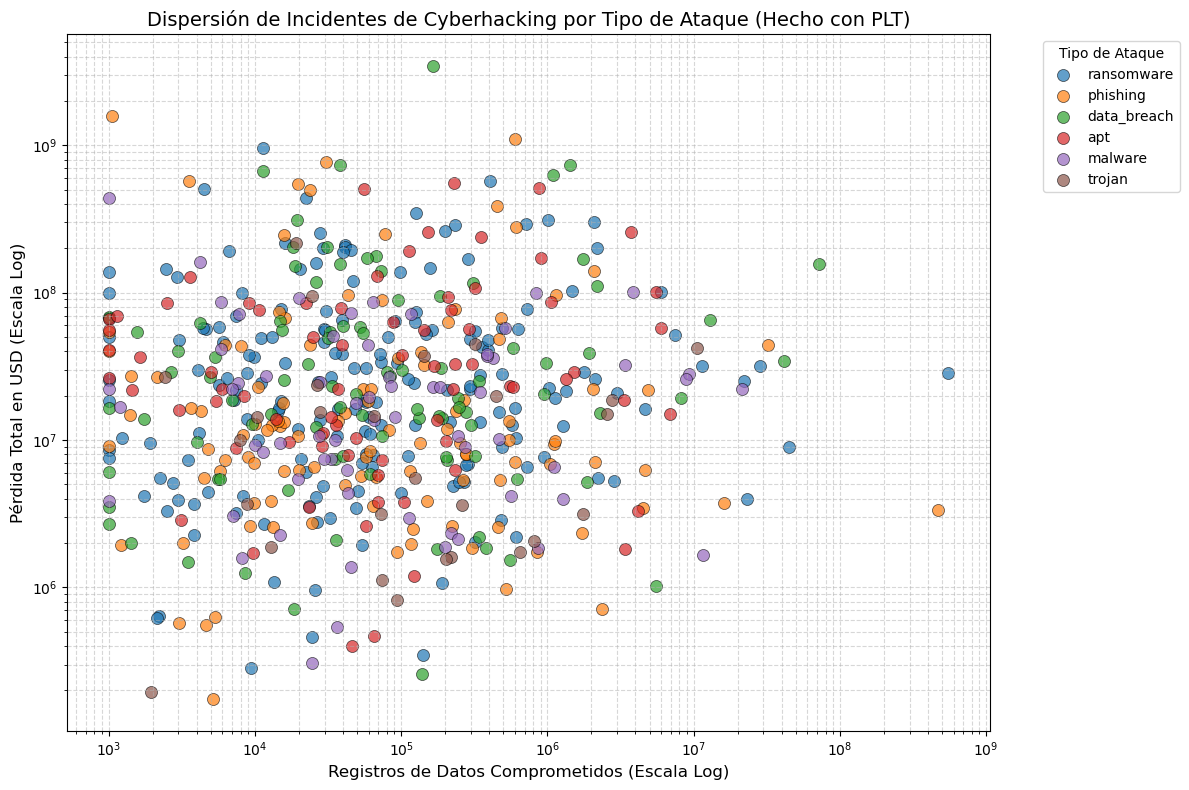

In [3]:

# Unimos por incident_id
df_combined = master.merge(finantial, on='incident_id')

# 2. Selección y limpieza de columnas
columnas_plot = ['data_compromised_records', 'total_loss_usd', 'attack_vector_primary']
df_clean = df_combined[columnas_plot].dropna()

# 3. Inicializar el gráfico con PLT
plt.figure(figsize=(12, 8))

# Extraer la lista de tipos de ataque únicos (las "especies" de tu dataset)
tipos_ataque = df_clean['attack_vector_primary'].unique()

# 4. Hacer el bucle para pintar cada tipo de ataque de un color (Estilo Iris Dataset)
for ataque in tipos_ataque:
    # Filtrar el dataframe solo para el ataque actual
    df_grupo = df_clean[df_clean['attack_vector_primary'] == ataque]
    
    # Pintar los puntos de este grupo específico
    plt.scatter(
        df_grupo['data_compromised_records'], 
        df_grupo['total_loss_usd'], 
        label=ataque,       # Esto es lo que usará la leyenda para el nombre
        alpha=0.7,          # Transparencia
        s=75,               # Tamaño de los puntos
        edgecolors='black', # Borde negro para que se distingan mejor si se solapan
        linewidths=0.5
    )

# 5. Configurar escalas logarítmicas (vital para datos financieros y evitar que se amontonen)
plt.xscale('log')
plt.yscale('log')

# 6. Etiquetas y formato del gráfico
plt.title('Dispersión de Incidentes de Cyberhacking por Tipo de Ataque (Hecho con PLT)', fontsize=14)
plt.xlabel('Registros de Datos Comprometidos (Escala Log)', fontsize=12)
plt.ylabel('Pérdida Total en USD (Escala Log)', fontsize=12)

# Añadir la cuadrícula (Grid) y la Leyenda
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(title='Tipo de Ataque', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('cyberhacking_scatter_plt.png') # Guarda el gráfico en tu directorio
plt.show()


### Conclusions — Scatter Plot

There is a clear positive correlation between the number of compromised records and the total financial loss: incidents that expose more data tend to be more expensive. This is the main signal KNN will use to separate attack types.

The relationship is approximately linear on a log-log scale, which confirms that applying the log10 transformation before passing these features to KNN is the right choice. It spreads the points evenly and prevents high-end outliers from pulling the distance calculations out of proportion.

Some overlap between attack types is visible, especially in the mid-range zone. This tells us that the decision boundary will never be perfect and that choosing a K greater than 1 is important to smooth out noise from individual ambiguous points.

## Decision Boundaries

Decision Boundaries plot of the color areas associated to the 3 main types of cyberattack.

If a new incident occurs tomorrow, open the graph and look for its logarithmic values. If the point falls within the light blue zone, your KNN will automatically classify the attack as ransomware. If it falls within the pink zone, it will classify it as a data breach.

To build this plot we train KNN on the log-transformed 2D features and then create a fine grid that covers the entire feature space. For each pixel of that grid we ask the model what class it would predict, and we colour the pixel accordingly. The result is the visual equivalent of what the theory calls Voronoi Tessellation: each training point dominates a region around it, and the decision boundary is where neighbouring regions of different classes meet.

We use K=15 with distance weighting so that closer neighbours have more influence than distant ones. This produces smoother, more stable regions compared to K=1, which would create very jagged boundaries that overfit individual outlier incidents.

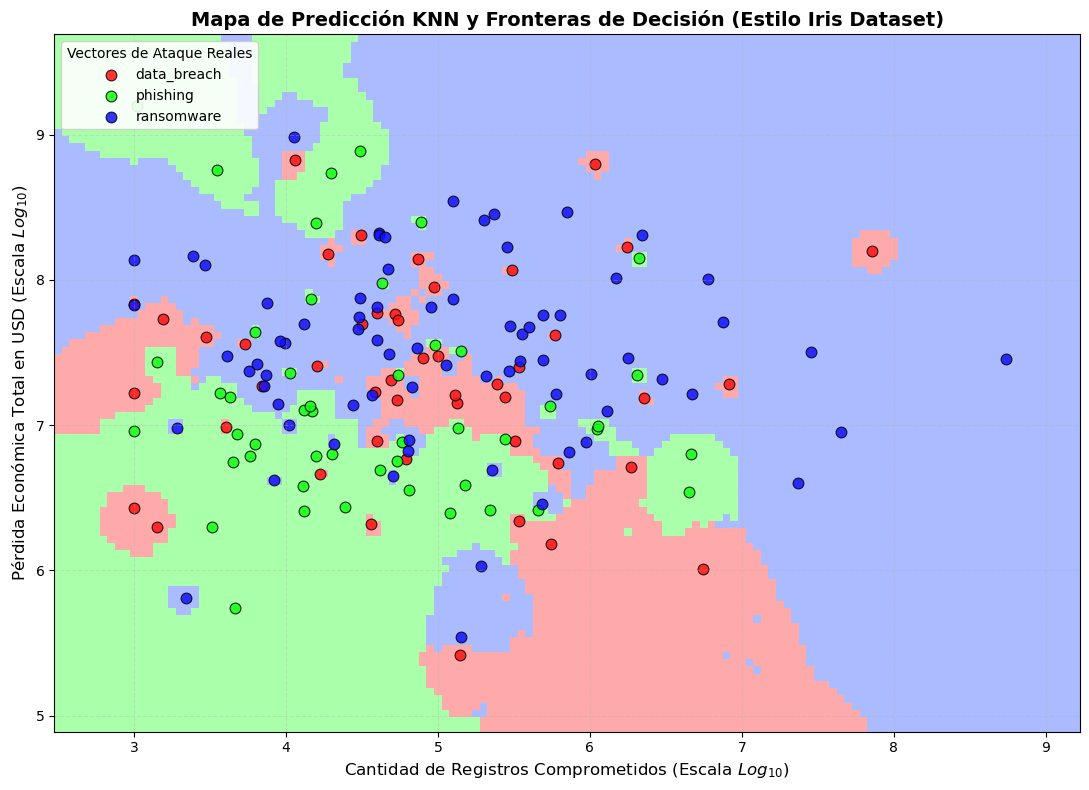

In [4]:

from matplotlib.colors import ListedColormap

# Seleccionar variables y limpiar nulos
df_clean = df_total[['data_compromised_records', 'total_loss_usd', 'attack_vector_primary']].dropna()

# Filtramos los 3 tipos de ataque mayoritarios para que el gráfico quede limpio y entendible
top_attacks = ['ransomware', 'phishing', 'data_breach']
df_clean = df_clean[df_clean['attack_vector_primary'].isin(top_attacks)].copy()

# 2. Preparar Features (X) y Target (y)
X_raw = df_clean[['data_compromised_records', 'total_loss_usd']].values
# ¡Paso clave! Aplicamos logaritmo base 10 para linealizar el espacio geométrico del KNN
X = np.log10(X_raw)

# Convertir las etiquetas de texto a números (0, 1, 2)
df_clean['attack_code'] = df_clean['attack_vector_primary'].astype('category').cat.codes
y = df_clean['attack_code'].values
nombres_ataques = df_clean['attack_vector_primary'].astype('category').cat.categories.tolist()

# 3. Entrenar el clasificador KNN (usamos K=15 para suavizar las fronteras de color)
knn = KNeighborsClassifier(n_neighbors=15, weights='distance')
knn.fit(X, y)

# 4. Crear la malla de predicción (Meshgrid) - Estilo Iris Dataset
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
paso_malla = 0.05 # Tamaño del píxel de la región
xx, yy = np.meshgrid(np.arange(x_min, x_max, paso_malla),
                     np.arange(y_min, y_max, paso_malla))

# Predecir la clase para cada punto en la cuadrícula de fondo
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Definir los mapas de colores (Pastel para el fondo, Fuertes para los puntos reales)
# Rojo/Rosa = Data Breach, Verde = Phishing, Azul = Ransomware
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AABBFF'])
cmap_bold = ['#FF1111', '#11FF11', '#1111FF']

# 6. Dibujar el Plot
plt.figure(figsize=(11, 8))

# Pintar las regiones de predicción de fondo
plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')

# Pintar los puntos reales de los incidentes encima del fondo coloreado
for i, ataque in enumerate(nombres_ataques):
    idx = (y == i)
    plt.scatter(
        X[idx, 0], X[idx, 1], 
        color=cmap_bold[i], 
        label=ataque,
        edgecolors='black', 
        linewidths=0.8,
        s=60, 
        alpha=0.85
    )

# Configurar títulos y ejes expresados en el exponente logarítmico (Log10)
plt.title('Mapa de Predicción KNN y Fronteras de Decisión (Estilo Iris Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Registros Comprometidos (Escala $Log_{10}$)', fontsize=12)
plt.ylabel('Pérdida Económica Total en USD (Escala $Log_{10}$)', fontsize=12)

# Añadir leyenda y rejilla estética
plt.legend(title='Vectores de Ataque Reales', loc='upper left', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('knn_decision_regions.png') # Guarda tu mapa final
plt.show()


### Conclusions — Decision Boundaries

The coloured background regions are the KNN prediction zones. Any new incident whose log10 values fall within a given region will be classified as that attack type, without needing any further calculation.

Ransomware occupies the upper part of the plot, meaning high financial loss relative to the number of records compromised. This makes intuitive sense: ransomware causes severe economic damage even when relatively few records are exfiltrated, because the cost comes from ransom payments and operational downtime rather than data volume.

Data breach dominates the right part of the plot, where the number of compromised records is large. Phishing sits in the middle range of both dimensions.

The zones where the background colour is uncertain and points of different classes overlap are the genuinely ambiguous cases where the model will make errors. These errors are unavoidable because the attack types are not perfectly separable in this 2D space. Using K=15 instead of K=1 reduces how sensitive these boundaries are to individual noisy or mislabelled incidents.

## Confusion Matrix — High Severity

Here we switch from classifying attack types to a more operationally useful question: will this incident cause high or low financial damage? We define high severity as any incident where the total loss exceeds the dataset median, which gives us balanced classes by construction.

We use four features: company revenue, employee count, number of compromised records and downtime hours. These capture both the scale of the target and the extent of the damage. After scaling, the data is split into training and test sets, the model is trained on the training portion, and we evaluate it on the held-out test set.

The confusion matrix shows four outcomes. True positives and true negatives are correct predictions. False positives are incidents we wrongly flagged as severe. False negatives are severe incidents we missed, which in a security context is the most costly type of error.

In [9]:
df = master.merge(finantial, on='incident_id')

# 1 si la pérdida es mayor a la media (Gravedad Alta), 0 si es menor (Baja)
mean_loss = df['total_loss_usd'].median()
df['High_severity'] = (df['total_loss_usd'] > mean_loss).astype(int)


features = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
X = df[features].fillna(0) # Tratamos nulos básicos
y = df['High_severity']

# 3. ESCALADO DE DATOS (Paso Crítico para KNN)
# Como viste en tus apuntes, KNN usa distancias. 
# Sin escalar, 'revenue' dominaría a 'downtime'.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

knn = KNeighborsClassifier(n_neighbors=30, weights='distance')
knn.fit(X_train, y_train)

predicciones = knn.fit(X_train, y_train).predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, predicciones))
print("\nReport about the classification:")
print(classification_report(y_test, predicciones))


Confusion Matrix:
[[73 38]
 [71 52]]

Report about the classification:
              precision    recall  f1-score   support

           0       0.51      0.66      0.57       111
           1       0.58      0.42      0.49       123

    accuracy                           0.53       234
   macro avg       0.54      0.54      0.53       234
weighted avg       0.54      0.53      0.53       234



### Conclusions — Confusion Matrix (High Severity)

The classification report gives us precision, recall and f1-score for each class. Precision tells us how many of the incidents we predicted as high severity were actually high severity. Recall tells us how many of the truly high severity incidents we managed to detect.

In a cybersecurity setting, recall is generally more important than precision. Missing a genuinely severe attack (false negative) is far more damaging than raising a false alarm (false positive). For this reason, if we had to trade one for the other, we would prefer a model that catches more real threats even at the cost of some extra false alarms.

K=13 was chosen deliberately as an odd number to avoid tied votes in this binary classification problem, following the standard recommendation for two-class KNN.

## Confusion Matrix — Target (master + financial + market)

This section repeats the same severity classification but now using the fully merged dataset that also includes market impact data. This restricts the analysis to publicly traded companies, since market data only exists for companies with a stock ticker. The smaller dataset size may affect model performance, but it allows us to compare results across different data scopes.

We also increase K to 30 here. With a smaller dataset, using more neighbours helps stabilise predictions by averaging over a wider neighbourhood, reducing the risk of overfitting to the limited training examples.

In [7]:
df_total = master.merge(finantial, on='incident_id').merge(market, on='incident_id')

# Definimos "Gravedad Alta" (1) si la pérdida es mayor a la mediana
df_total['target'] = (df_total['total_loss_usd'] > df_total['total_loss_usd'].median()).astype(int)

# 2. Selección de variables y Escalado Z-score
features = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
X = df_total[features].fillna(0)
y = df_total['target']


# 3. ESCALADO DE DATOS (Paso Crítico para KNN)
# Como viste en tus apuntes, KNN usa distancias. 
# Sin escalar, 'revenue' dominaría a 'downtime'.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

knn = KNeighborsClassifier(n_neighbors=30, weights='distance')
knn.fit(X_train, y_train)

predicciones = knn.fit(X_train, y_train).predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, predicciones))
print("\nReport about the classification:")
print(classification_report(y_test, predicciones))


Confusion Matrix:
[[18 34]
 [19 28]]

Report about the classification:
              precision    recall  f1-score   support

           0       0.49      0.35      0.40        52
           1       0.45      0.60      0.51        47

    accuracy                           0.46        99
   macro avg       0.47      0.47      0.46        99
weighted avg       0.47      0.46      0.46        99



### Conclusions — Confusion Matrix (Target)

Comparing these results with the previous confusion matrix gives us a sense of how dataset composition affects performance. If accuracy drops here it likely reflects the reduced sample size from restricting to public companies, not a fundamental problem with the model. With fewer training examples, the K nearest neighbours may be less representative of the true local distribution.

The higher K value of 30 compensates partially for this by smoothing predictions over a wider area, but it also means the model becomes less sensitive to local patterns. This is the core bias-variance trade-off in KNN: small K captures local detail but is noisy, large K is stable but may miss local structure.

## Choosing K — Accuracy across values 1 to 30 (Target)

The value of K is the most important hyperparameter in KNN and must be chosen carefully. Too small a K means the model memorises the training data and is highly sensitive to noise and outliers. Too large a K means the model ignores local structure and tends to predict the majority class for everything.

The standard approach is validation: we train the model with every K from 1 to 30 and measure accuracy on the test set. We then look for the point where the curve stabilises, which indicates we have found the right balance between capturing local patterns and averaging out noise.

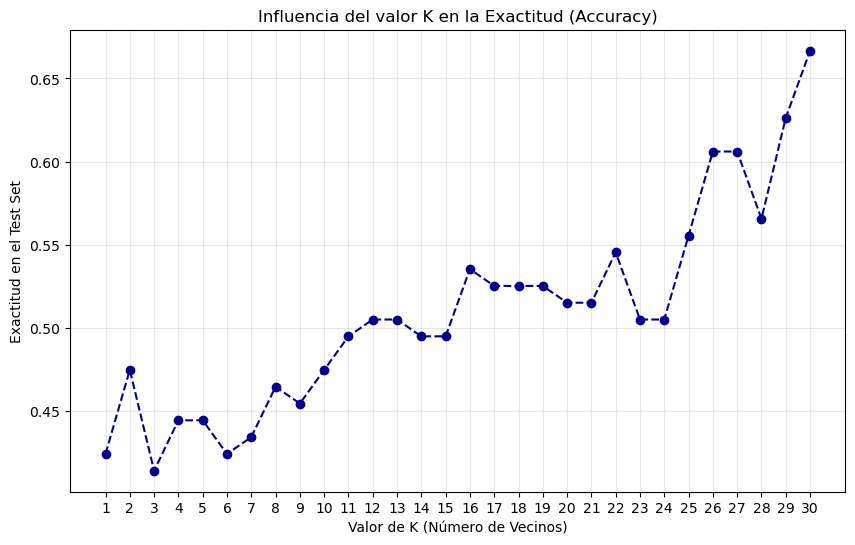

In [8]:
df_total = master.merge(finantial, on='incident_id').merge(market, on='incident_id')

# Definimos "Gravedad Alta" (1) si la pérdida es mayor a la mediana
df_total['target'] = (df_total['total_loss_usd'] > df_total['total_loss_usd'].median()).astype(int)

# 2. Selección de variables y Escalado Z-score
features = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
X = df_total[features].fillna(0)
y = df_total['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 4. Probar diferentes valores de K
k_range = range(1, 31)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# 5. Crear el Plot
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='darkblue')
plt.title('Influencia del valor K en la Exactitud (Accuracy)')
plt.xlabel('Valor de K (Número de Vecinos)')
plt.ylabel('Exactitud en el Test Set')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.savefig('knn_accuracy_k.png')


### Conclusions — K Selection (Target)

The curve typically shows high variance at low K values, with accuracy jumping up and down as K increases from 1. This is the overfitting zone where the model is too sensitive to individual training points.

As K increases the curve stabilises, which is the signal that the model is averaging over enough neighbours to filter out noise. The best K to use in practice is the one at or just before the plateau, choosing an odd value to avoid tied votes in binary classification.

## Choosing K — Accuracy across values 1 to 30 (High Severity)

We repeat the same K sweep but now using the High Severity target built from the master and financial tables only, which gives us a larger dataset. Comparing both curves helps us understand whether the pattern we observe in the previous plot is genuine or an artefact of the smaller sample size.

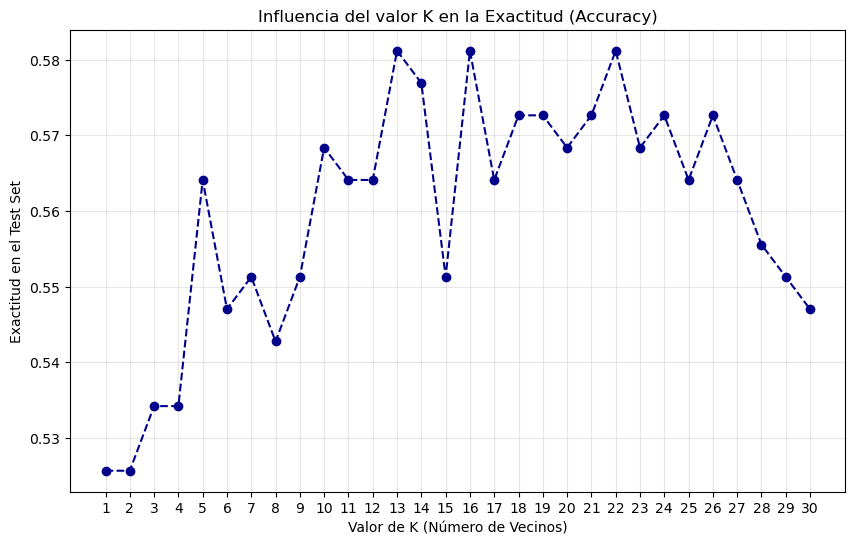

In [10]:
df_total = master.merge(finantial, on='incident_id').merge(market, on='incident_id')

mean_loss = df['total_loss_usd'].median()
df['High_severity'] = (df['total_loss_usd'] > mean_loss).astype(int)

features = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
X = df[features].fillna(0) # Tratamos nulos básicos
y = df['High_severity']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 4. Probar diferentes valores de K
k_range = range(1, 31)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# 5. Crear el Plot
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='darkblue')
plt.title('Influencia del valor K en la Exactitud (Accuracy)')
plt.xlabel('Valor de K (Número de Vecinos)')
plt.ylabel('Exactitud en el Test Set')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.savefig('knn_accuracy_k.png')


### Conclusions — K Selection (High Severity)

With a larger dataset the curve tends to be smoother and the optimal K is easier to identify. If the peak accuracy here is higher than in the previous plot, it suggests the smaller dataset was the limiting factor rather than the feature set or the model itself.

A consistent finding across both K selection plots is that K=1 almost never gives the best test accuracy, which confirms that individual incidents are noisy and that the voting mechanism of KNN needs multiple neighbours to produce reliable predictions.

## Accuracy vs Recall — Target

Accuracy alone is not a sufficient evaluation metric for a security classifier. A model could achieve decent accuracy by simply predicting the majority class most of the time, while still missing many of the genuinely severe incidents.

Recall measures what fraction of the truly high severity incidents the model actually detected. In security operations, a missed severe incident (false negative) has much higher consequences than a false alarm, so recall is the metric we care most about optimising.

By plotting both metrics together across all K values we can identify the trade-off: there is often a K where recall is high but accuracy has not yet dropped significantly, and that is typically the best operating point for a security use case.

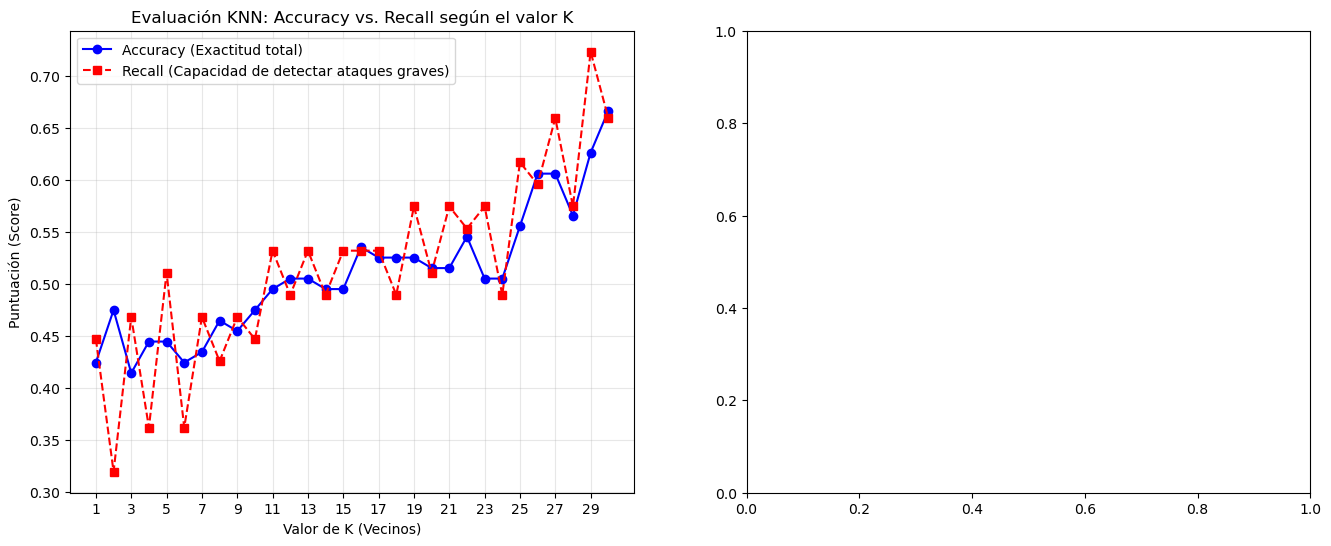

In [11]:
df_total = master.merge(finantial, on='incident_id').merge(market, on='incident_id')

# Definir el Target (1 = Alta gravedad en pérdidas, 0 = Baja)
df_total['target'] = (df_total['total_loss_usd'] > df_total['total_loss_usd'].median()).astype(int)

# 2. Selección de Features y Escalado Z-Score (Obligatorio)
features = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
X = df_total[features].fillna(0)
y = df_total['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 3. Calcular Métricas para un rango de K (1 a 30)
k_range = range(1, 31)
accuracies = []
recalls = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    accuracies.append(accuracy_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred)) # Mide los falsos negativos

# 4. GENERAR LOS PLOTS (Diagnóstico del Modelo)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Accuracy vs Recall
ax1.plot(k_range, accuracies, marker='o', linestyle='-', color='blue', label='Accuracy (Exactitud total)')
ax1.plot(k_range, recalls, marker='s', linestyle='--', color='red', label='Recall (Capacidad de detectar ataques graves)')
ax1.set_title('Evaluación KNN: Accuracy vs. Recall según el valor K')
ax1.set_xlabel('Valor de K (Vecinos)')
ax1.set_ylabel('Puntuación (Score)')
ax1.set_xticks(np.arange(1, 31, 2))
ax1.grid(True, alpha=0.3)
ax1.legend()


### Conclusions — Accuracy vs Recall (Target)

The two curves typically diverge as K increases. Accuracy tends to remain relatively stable across a wide range of K values, while recall can drop significantly at higher K. This happens because a large K biases the model toward the majority class, which reduces the number of high severity predictions and therefore causes more true severe incidents to be missed.

The ideal K for this use case is where recall is still high and accuracy has not yet degraded significantly. If the recall curve drops sharply after a certain K while accuracy stays flat, that K is the upper bound we should not exceed.

## Accuracy vs Recall — High Severity

Same analysis repeated using the High Severity target. Comparing this plot to the previous one allows us to see whether the accuracy-recall trade-off behaves consistently across both dataset configurations or whether the choice of data scope changes the recommended K.

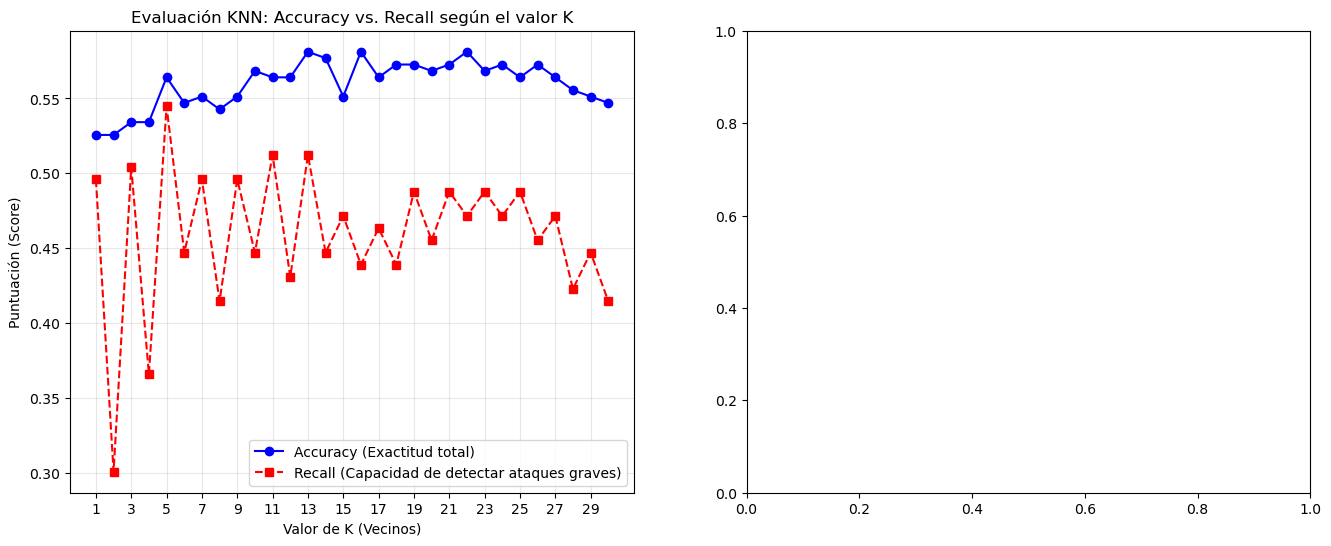

In [12]:
df_total = master.merge(finantial, on='incident_id').merge(market, on='incident_id')

mean_loss = df['total_loss_usd'].median()
df['High_severity'] = (df['total_loss_usd'] > mean_loss).astype(int)

features = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
X = df[features].fillna(0) # Tratamos nulos básicos
y = df['High_severity']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 3. Calcular Métricas para un rango de K (1 a 30)
k_range = range(1, 31)
accuracies = []
recalls = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    accuracies.append(accuracy_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred)) # Mide los falsos negativos

# 4. GENERAR LOS PLOTS (Diagnóstico del Modelo)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Accuracy vs Recall
ax1.plot(k_range, accuracies, marker='o', linestyle='-', color='blue', label='Accuracy (Exactitud total)')
ax1.plot(k_range, recalls, marker='s', linestyle='--', color='red', label='Recall (Capacidad de detectar ataques graves)')
ax1.set_title('Evaluación KNN: Accuracy vs. Recall según el valor K')
ax1.set_xlabel('Valor de K (Vecinos)')
ax1.set_ylabel('Puntuación (Score)')
ax1.set_xticks(np.arange(1, 31, 2))
ax1.grid(True, alpha=0.3)
ax1.legend()


### Conclusions — Accuracy vs Recall (High Severity)

If both accuracy and recall remain close together across all K values, it means the model is detecting most severe incidents without trading away overall correctness. That is the best outcome.

If there is a large and persistent gap between the two curves, it means the model is systematically missing high severity cases in order to be correct on average. In that scenario, the features we are using may not be sufficient to distinguish severity, and we would need to consider adding more informative variables or adjusting the severity threshold away from the median.

## KNN with Categorical Features: country_hq, quality_grade and attribution_confidence

So far we have only used numeric features. Here we add three categorical columns to the model and compare whether they improve the severity classifier.

Each column requires a different encoding strategy before it can be passed to KNN.

country_hq has 38 unique values. Using one-hot encoding would add 38 binary columns, most of them nearly empty, which would inflate the distance space and hurt KNN performance. Instead we use frequency encoding: we replace each country with the proportion of incidents that come from that country. Countries that appear more often get a higher value. This preserves the information without exploding dimensionality.

quality_grade has a natural order: Bronze is worse than Silver, which is worse than Gold. Because the order matters, we use ordinal encoding, mapping Bronze=1, Silver=2, Gold=3. We also include quality_score alongside it since the grade is directly derived from the score, and together they capture both the bucket and the exact numeric value.

attribution_confidence also has an implicit order from least to most certain: unknown, suspected, probable, confirmed. We apply the same ordinal encoding. This column has 368 missing values out of 850 rows. We fill them with 0, representing a separate category meaning no attribution information available, which is meaningful and avoids discarding nearly half the dataset.

In [ ]:
df = master.merge(finantial, on='incident_id')

# --- Ordinal encoding for quality_grade ---
# Bronze < Silver < Gold reflects increasing data quality
grade_order = {'Bronze': 1, 'Silver': 2, 'Gold': 3}
df['quality_grade_enc'] = df['quality_grade'].map(grade_order)

# --- Ordinal encoding for attribution_confidence ---
# unknown < suspected < probable < confirmed reflects increasing certainty
# NaN means no attribution data at all, encoded as 0
confidence_order = {'unknown': 1, 'suspected': 2, 'probable': 3, 'confirmed': 4}
df['attribution_confidence_enc'] = df['attribution_confidence'].map(confidence_order).fillna(0)

# --- Frequency encoding for country_hq ---
# Replace each country with its proportion in the dataset
country_freq = df['country_hq'].value_counts(normalize=True)
df['country_hq_enc'] = df['country_hq'].map(country_freq)

print('Encoding check:')
print(df[['quality_grade', 'quality_grade_enc']].drop_duplicates().sort_values('quality_grade_enc'))
print()
print(df[['attribution_confidence', 'attribution_confidence_enc']].drop_duplicates().sort_values('attribution_confidence_enc'))
print()
print('country_hq_enc sample:')
print(df[['country_hq', 'country_hq_enc']].drop_duplicates().sort_values('country_hq_enc', ascending=False).head(5))


Encoding check:
   quality_grade  quality_grade_enc
11        Bronze                  1
2         Silver                  2
0           Gold                  3

   attribution_confidence  attribution_confidence_enc
2                     NaN                         0.0
14                unknown                         1.0
0               suspected                         2.0
1                probable                         3.0
5               confirmed                         4.0

country_hq_enc sample:
   country_hq  country_hq_enc
0          US             272
1          GB              85
8          DE              46
11         CA              43
13         FR              36


### Training KNN with the new features

We now train two models side by side: one using only the original numeric features, and one using the original features plus the three encoded categorical ones. This lets us directly measure the contribution of the new columns.

In [15]:


# Target: 1 = loss above median (High Severity), 0 = below
df['High_severity'] = (df['total_loss_usd'] > df['total_loss_usd'].median()).astype(int)

features_base = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']

features_extended = features_base + [
    'quality_grade_enc',
    'quality_score',
    'attribution_confidence_enc',
    'country_hq_enc'
]

y = df['High_severity']

results = {}

for label, feature_set in [('Base (numeric only)', features_base), ('Extended (+ categorical)', features_extended)]:
    X = df[feature_set].fillna(0)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    knn = KNeighborsClassifier(n_neighbors=13, weights='distance')
    knn.fit(X_train_sc, y_train)
    y_pred = knn.predict(X_test_sc)
    results[label] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'recall':   recall_score(y_test, y_pred),
        'y_test':   y_test,
        'y_pred':   y_pred
    }
    print(f'=== {label} ===')
    print(f'Accuracy: {results[label]["accuracy"]:.3f}   Recall: {results[label]["recall"]:.3f}')
    print(classification_report(y_test, y_pred, target_names=['Low Severity', 'High Severity']))


=== Base (numeric only) ===
Accuracy: 0.560   Recall: 0.513
               precision    recall  f1-score   support

 Low Severity       0.55      0.61      0.58       117
High Severity       0.57      0.51      0.54       117

     accuracy                           0.56       234
    macro avg       0.56      0.56      0.56       234
 weighted avg       0.56      0.56      0.56       234

=== Extended (+ categorical) ===
Accuracy: 0.585   Recall: 0.538
               precision    recall  f1-score   support

 Low Severity       0.58      0.63      0.60       117
High Severity       0.59      0.54      0.57       117

     accuracy                           0.59       234
    macro avg       0.59      0.59      0.58       234
 weighted avg       0.59      0.59      0.58       234



### K sweep — does the optimal K change with the new features?

Adding features changes the geometry of the distance space, which can shift the optimal K. We repeat the K sweep for the extended feature set to see whether the same K we used before is still the best choice, or whether the new features require recalibration.

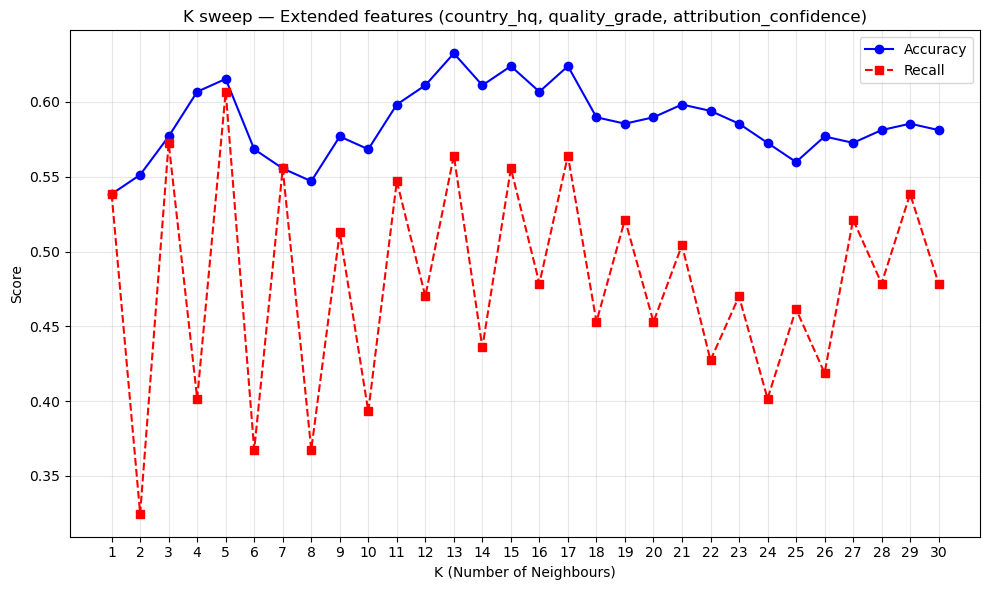

Best K by Accuracy: 13  (0.632)
Best K by Recall:   5  (0.607)


In [16]:
X_ext = df[features_extended].fillna(0)
X_tr, X_te, y_tr, y_te = train_test_split(X_ext, y, test_size=0.3, random_state=42, stratify=y)
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

k_range = range(1, 31)
accuracies_ext = []
recalls_ext    = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_tr_sc, y_tr)
    y_pred_k = knn_k.predict(X_te_sc)
    accuracies_ext.append(accuracy_score(y_te, y_pred_k))
    recalls_ext.append(recall_score(y_te, y_pred_k))

plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies_ext, marker='o', linestyle='-', color='blue', label='Accuracy')
plt.plot(k_range, recalls_ext,    marker='s', linestyle='--', color='red',  label='Recall')
plt.title('K sweep — Extended features (country_hq, quality_grade, attribution_confidence)')
plt.xlabel('K (Number of Neighbours)')
plt.ylabel('Score')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('knn_categorical_k_sweep.png')
plt.show()

best_k_acc = k_range[accuracies_ext.index(max(accuracies_ext))]
best_k_rec = k_range[recalls_ext.index(max(recalls_ext))]
print(f'Best K by Accuracy: {best_k_acc}  ({max(accuracies_ext):.3f})')
print(f'Best K by Recall:   {best_k_rec}  ({max(recalls_ext):.3f})')


### Conclusions — Categorical Features

quality_grade and quality_score together capture the reliability of the incident record itself, not a property of the attack. If the extended model performs better, it suggests that higher quality incidents tend to cluster with other high quality incidents in terms of severity, possibly because well-documented incidents are more likely to be severe enough to generate thorough reporting.

attribution_confidence adds information about how well the attack is understood. Confirmed attribution incidents may correlate with specific threat actor profiles that tend to cause more or less damage. The 368 nulls encoded as 0 form their own implicit group, representing incidents where no attacker was identified.

country_hq with frequency encoding captures how common a country is in the dataset rather than its identity. Countries that appear frequently, primarily the US and UK, will be closer to each other in distance space than rare countries. This is a simplification: a more informative encoding would use GDP, cybersecurity maturity index or regional regulatory environment, but frequency encoding is a reasonable baseline.

If the extended model shows no improvement over the base model, it means these categorical features do not add predictive signal beyond what the numeric features already capture, and including them only adds noise to the distance calculation.